# Panel Float Scatter From Saved Fit

This notebook does not fit models again. It loads saved `smooth / segmented / hybrid` curves from `data/float_fit_rel_curves.json` and draws:

- left: scatter for relative target `predicted / base - 1`
- right: scatter for predicted price with saved curves converted back to price


In [15]:
from __future__ import annotations

import base64
import io
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

STRUCTURAL_GAP = -1337.0
DATA_DIR = Path("../skin_homog/data_skins_big")
FIT_JSON = Path("data/float_fit_rel_curves.json")
PANEL_FILES = {
    "base": "base.csv",
    "predicted": "predicted.csv",
    "float_value": "float_value.csv",
    "sticker_count": "sticker_count.csv",
}
MIN_LISTINGS = 5
MAX_PLOTS = None
OUTLIER_NEIGHBORS = 6
OUTLIER_Z = 3.5
OUTLIER_MIN_ABS_DEV = 0.03
MODEL_COLORS = {
    "smooth": "tab:blue",
    "segmented": "tab:orange",
    "hybrid": "tab:green",
}


In [16]:
def load_numeric_panel(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.apply(pd.to_numeric, errors="coerce")
    return df.replace(STRUCTURAL_GAP, np.nan)


def build_item_df(item: str, panels: dict[str, pd.DataFrame]) -> pd.DataFrame:
    df = pd.DataFrame(
        {
            "float_value": panels["float_value"][item],
            "base": panels["base"][item],
            "predicted": panels["predicted"][item],
            "sticker_count": panels["sticker_count"][item],
        }
    )
    df["pred_rel_dev"] = df["predicted"] / df["base"] - 1.0
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["float_value", "base", "predicted", "pred_rel_dev"])
    return df.sort_values("float_value").reset_index(drop=True)


def local_outlier_mask(
    x: np.ndarray,
    y: np.ndarray,
    neighbors: int = OUTLIER_NEIGHBORS,
    z_thresh: float = OUTLIER_Z,
    min_abs_dev: float = OUTLIER_MIN_ABS_DEV,
) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    if n < max(5, neighbors):
        return np.zeros(n, dtype=bool)

    mask = np.zeros(n, dtype=bool)
    k = min(max(3, neighbors), n - 1)
    for i in range(n):
        d = np.abs(x - x[i])
        d[i] = np.inf
        idx = np.argpartition(d, k)[:k]
        y_loc = y[idx]
        med = float(np.median(y_loc))
        mad = float(np.median(np.abs(y_loc - med)))
        scale = max(1.4826 * mad, 1e-6)
        resid = y[i] - med
        z = abs(resid) / scale
        if abs(resid) >= min_abs_dev and z >= z_thresh:
            left = y[idx][x[idx] < x[i]]
            right = y[idx][x[idx] > x[i]]
            if len(left) > 0 and len(right) > 0:
                left_med = float(np.median(left))
                right_med = float(np.median(right))
                side_gap = abs(left_med - right_med)
                if side_gap < abs(resid) * 0.6:
                    mask[i] = True
            else:
                mask[i] = True
    return mask


def fig_to_base64(fig) -> str:
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode("ascii")


def compute_visible_ylim(main_y: np.ndarray, extra_series: list[np.ndarray], pad_frac: float = 0.08) -> tuple[float, float]:
    parts = [np.asarray(main_y, dtype=float)]
    for arr in extra_series:
        parts.append(np.asarray(arr, dtype=float))
    vals = np.concatenate([a[np.isfinite(a)] for a in parts if np.isfinite(a).any()])
    if len(vals) == 0:
        return (-1.0, 1.0)
    y_min = float(np.min(vals))
    y_max = float(np.max(vals))
    if not np.isfinite(y_min) or not np.isfinite(y_max):
        return (-1.0, 1.0)
    if y_min == y_max:
        pad = max(abs(y_min) * pad_frac, 1e-3)
        return (y_min - pad, y_max + pad)
    pad = max((y_max - y_min) * pad_frac, 1e-6)
    return (y_min - pad, y_max + pad)


def scatter_clipped_outliers(ax, x_all: np.ndarray, y_all: np.ndarray, out_mask: np.ndarray, y_lim: tuple[float, float], **kwargs):
    if np.sum(out_mask) <= 0:
        return
    y_lo, y_hi = y_lim
    vis_mask = out_mask & np.isfinite(y_all) & (y_all >= y_lo) & (y_all <= y_hi)
    if np.sum(vis_mask) <= 0:
        return
    ax.scatter(x_all[vis_mask], y_all[vis_mask], **kwargs)


panels = {name: load_numeric_panel(DATA_DIR / filename) for name, filename in PANEL_FILES.items()}
with open(FIT_JSON, encoding="utf-8") as f:
    fit_payload = json.load(f)
fit_per_skin = fit_payload.get("per_skin", {})

common_items = sorted(set.intersection(*(set(df.columns) for df in panels.values())) & set(fit_per_skin.keys()))
if MAX_PLOTS is not None:
    common_items = common_items[:MAX_PLOTS]

len(common_items), common_items[:5]


(956,
 ['AK-47 | Aphrodite (Minimal Wear)',
  'AK-47 | Aquamarine Revenge (Battle-Scarred)',
  'AK-47 | Aquamarine Revenge (Field-Tested)',
  'AK-47 | Aquamarine Revenge (Minimal Wear)',
  'AK-47 | Aquamarine Revenge (Well-Worn)'])

In [17]:
TARGET_ITEM = "Desert Eagle | Crimson Web (Minimal Wear)"  

item: Desert Eagle | Crimson Web (Minimal Wear)
rows: 186
fit keys: ['n_raw', 'n_clean', 'outlier_n', 'x_min', 'x_max', 'mae_smooth_clean', 'mae_supersmooth_clean', 'mae_segmented_clean', 'continuity_ratio', 'continuity_ratio2', 'splits', 'x_grid', 'smooth', 'segmented', 'hybrid']
curve lengths: {'smooth': 300, 'segmented': 300, 'hybrid': 300}
x_grid len: 300
continuity_ratio: 1.4843697494432053
continuity_ratio2: 1.7812239620374968
mae_smooth_clean: 0.006938047074125929
mae_supersmooth_clean: 0.00832556423546955
mae_segmented_clean: 0.0046740692989253015


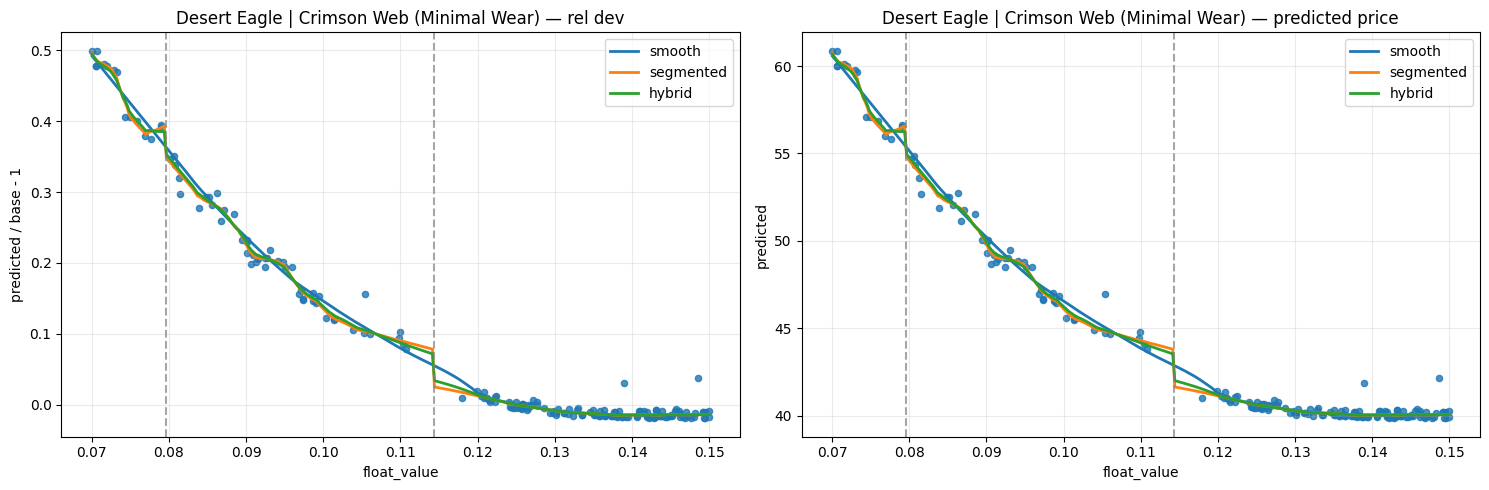

In [18]:
SHOW_OUTLIER_CROSSES = False

if TARGET_ITEM not in common_items:
    raise ValueError(f"Item not found: {TARGET_ITEM}")

item = TARGET_ITEM
fit = fit_per_skin[item]
item_df = build_item_df(item, panels)

print("item:", item)
print("rows:", len(item_df))
print("fit keys:", list(fit.keys()))

x = item_df["float_value"].to_numpy(dtype=float)
base = item_df["base"].to_numpy(dtype=float)
pred = item_df["predicted"].to_numpy(dtype=float)
y_rel = item_df["pred_rel_dev"].to_numpy(dtype=float)

out_mask = local_outlier_mask(x, y_rel)
x_grid = np.asarray(fit["x_grid"], dtype=float)
splits = fit.get("splits", [])

curves = {}
for name in ("smooth", "segmented", "hybrid"):
    if name in fit:
        curves[name] = np.asarray(fit[name], dtype=float)

print("curve lengths:", {k: len(v) for k, v in curves.items()})
print("x_grid len:", len(x_grid))
print("continuity_ratio:", fit.get("continuity_ratio"))
print("continuity_ratio2:", fit.get("continuity_ratio2"))
print("mae_smooth_clean:", fit.get("mae_smooth_clean"))
print("mae_supersmooth_clean:", fit.get("mae_supersmooth_clean"))
print("mae_segmented_clean:", fit.get("mae_segmented_clean"))

base_grid = np.interp(x_grid, x, base)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1, ax2 = axes

ax1.scatter(x, y_rel, s=20, alpha=0.8)
if SHOW_OUTLIER_CROSSES and out_mask.any():
    ax1.scatter(x[out_mask], y_rel[out_mask], color="crimson", marker="x", s=60)

for model_name, curve in curves.items():
    ax1.plot(x_grid, curve, color=MODEL_COLORS[model_name], linewidth=2, label=model_name)

for split_x in splits:
    ax1.axvline(split_x, color="gray", linestyle="--", alpha=0.7)

ax1.set_title(f"{item} — rel dev")
ax1.set_xlabel("float_value")
ax1.set_ylabel("predicted / base - 1")
ax1.grid(True, alpha=0.25)
ax1.legend()

ax2.scatter(x, pred, s=20, alpha=0.8)
if SHOW_OUTLIER_CROSSES and out_mask.any():
    ax2.scatter(x[out_mask], pred[out_mask], color="crimson", marker="x", s=60)

for model_name, curve in curves.items():
    ax2.plot(x_grid, base_grid * (1.0 + curve), color=MODEL_COLORS[model_name], linewidth=2, label=model_name)

for split_x in splits:
    ax2.axvline(split_x, color="gray", linestyle="--", alpha=0.7)

ax2.set_title(f"{item} — predicted price")
ax2.set_xlabel("float_value")
ax2.set_ylabel("predicted")
ax2.grid(True, alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()




In [19]:
# cards = []

# for item in common_items:
#     item_df = build_item_df(item, panels)
#     if len(item_df) < MIN_LISTINGS:
#         continue

#     fit = fit_per_skin.get(item)
#     if not isinstance(fit, dict):
#         continue

#     x = item_df["float_value"].to_numpy(dtype=float)
#     y_rel = item_df["pred_rel_dev"].to_numpy(dtype=float)
#     y_price = item_df["predicted"].to_numpy(dtype=float)
#     base = item_df["base"].to_numpy(dtype=float)
#     out_mask = local_outlier_mask(x, y_rel)

#     x_grid = np.asarray(fit["x_grid"], dtype=float)
#     rel_curves = {
#         name: np.asarray(fit[name], dtype=float)
#         for name in ("smooth", "segmented", "hybrid")
#     }
#     base_grid = np.interp(x_grid, x, base)
#     price_curves = {
#         name: base_grid * (1.0 + rel_curve)
#         for name, rel_curve in rel_curves.items()
#     }

#     fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2))

#     ax = axes[0]
#     sc = ax.scatter(
#         item_df["float_value"],
#         item_df["pred_rel_dev"],
#         c=item_df["sticker_count"],
#         cmap="viridis",
#         s=32,
#         alpha=0.8,
#     )
#     rel_ylim = compute_visible_ylim(y_rel[~out_mask], list(rel_curves.values()))
#     for model_name, curve in rel_curves.items():
#         ax.plot(x_grid, curve, color=MODEL_COLORS[model_name], linewidth=2.0, label=model_name)
#     scatter_clipped_outliers(
#         ax,
#         x,
#         y_rel,
#         out_mask,
#         rel_ylim,
#         marker="x",
#         s=84,
#         linewidths=2.0,
#         color="crimson",
#         label="local outlier",
#     )
#     ax.set_ylim(*rel_ylim)
#     ax.set_title("Target: predicted / base - 1")
#     ax.set_xlabel("Float")
#     ax.set_ylabel("Relative deviation")
#     ax.grid(alpha=0.18)
#     ax.legend(fontsize=8, loc="best")

#     ax = axes[1]
#     ax.scatter(
#         item_df["float_value"],
#         item_df["predicted"],
#         c=item_df["sticker_count"],
#         cmap="viridis",
#         s=32,
#         alpha=0.8,
#     )
#     price_ylim = compute_visible_ylim(y_price[~out_mask], list(price_curves.values()))
#     for model_name, curve in price_curves.items():
#         ax.plot(x_grid, curve, color=MODEL_COLORS[model_name], linewidth=2.0, label=model_name)
#     scatter_clipped_outliers(
#         ax,
#         x,
#         y_price,
#         out_mask,
#         price_ylim,
#         marker="x",
#         s=84,
#         linewidths=2.0,
#         color="crimson",
#         label="local outlier",
#     )
#     ax.set_ylim(*price_ylim)
#     ax.set_title("Predicted price")
#     ax.set_xlabel("Float")
#     ax.set_ylabel("Price")
#     ax.grid(alpha=0.18)
#     ax.legend(fontsize=8, loc="best")

#     cbar = fig.colorbar(sc, ax=axes, fraction=0.03, pad=0.02)
#     cbar.set_label("Sticker count")

#     continuity_ratio = fit.get("continuity_ratio")
#     continuity_ratio2 = fit.get("continuity_ratio2")
#     mae_smooth_clean = fit.get("mae_smooth_clean")
#     mae_supersmooth_clean = fit.get("mae_supersmooth_clean")
#     mae_segmented_clean = fit.get("mae_segmented_clean")
#     continuity_text = (
#         f"continuity_ratio={float(continuity_ratio):.2f}"
#         if continuity_ratio is not None and np.isfinite(float(continuity_ratio))
#         else "continuity_ratio=-"
#     )
#     continuity2_text = (
#         f"continuity_ratio2={float(continuity_ratio2):.2f}"
#         if continuity_ratio2 is not None and np.isfinite(float(continuity_ratio2))
#         else "continuity_ratio2=-"
#     )
#     mae_text = (
#         f"mae_s/seg={float(mae_smooth_clean):.4f}/{float(mae_segmented_clean):.4f}"
#         if mae_smooth_clean is not None and mae_segmented_clean is not None
#         and np.isfinite(float(mae_smooth_clean)) and np.isfinite(float(mae_segmented_clean))
#         else "mae_s/seg=-"
#     )
#     mae2_text = (
#         f"mae_ss/seg={float(mae_supersmooth_clean):.4f}/{float(mae_segmented_clean):.4f}"
#         if mae_supersmooth_clean is not None and mae_segmented_clean is not None
#         and np.isfinite(float(mae_supersmooth_clean)) and np.isfinite(float(mae_segmented_clean))
#         else "mae_ss/seg=-"
#     )
#     fig.suptitle(f"{item} | {continuity_text} | {continuity2_text}", fontsize=13, y=1.02)
#     img_b64 = fig_to_base64(fig)
#     cards.append(
#         f"<div style='margin: 0 0 18px 0; border: 1px solid #ddd; border-radius: 10px; padding: 12px; background: white;'>"
#         f"<div style='font: 600 14px sans-serif; margin-bottom: 6px;'>{item}</div>"
#         f"<div style='font: 12px sans-serif; color: #555; margin-bottom: 8px;'>n={len(item_df)} | outliers={int(out_mask.sum())} | clean={int((~out_mask).sum())} | splits={len(fit.get('splits', []))} | {continuity_text} | {continuity2_text} | {mae_text} | {mae2_text}</div>"
#         f"<img src='data:image/png;base64,{img_b64}' style='max-width: 100%; height: auto;'/>"
#         f"</div>"
#     )

# display(
#     HTML(
#         "<div style='max-height: 78vh; overflow-y: auto; padding-right: 8px;'>"
#         + "".join(cards)
#         + "</div>"
#     )
# )
